# Variability classification for a single brown dwarf spectrum

Classify a brown dwarf spectrum as a candidate variable or non-variable using the NIR spectral-index variability scheme implemented in `seda.classify_variability`.

This tutorial shows how to:
- read an input spectrum,
- run the variability classification for either an L or T dwarf scheme,
- inspect the output stored in the `VariabilityResult` object,
- and optionally generate diagnostic plots of the index bandpasses and the index–index variability diagrams.

In [13]:
import seda
from seda.variability import classify_variability
import numpy as np
import os
from astropy.io import ascii
from numpy.typing import ArrayLike
from typing import Tuple, Literal, Optional, Union, Dict, List, Mapping
from matplotlib import Path

### Read the spectrum of interest

As an example, let us read a near-infrared brown dwarf spectrum.
You can replace this file by your own spectrum, as long as it contains wavelength and flux columns.

In [4]:
# path to the seda package
#path_seda = os.path.dirname(os.path.dirname(seda.__file__))

#spec_name = path_seda + '/docs/notebooks/data/0439-nirspec-Ldwarf.txt'
spec_name = '/Users/arrecifecosmico/seda/docs/notebooks/data/0439-nirspec-Ldwarf.txt'
spec = np.loadtxt(spec_name, comments='#').T

wave = spec[0]   # wavelength in microns
flux = spec[1]   # flux

If your input file contains uncertainties, you can still use them for your own bookkeeping, but the variability module currently requires only wavelength and flux arrays.

### Explore the function documentation
As for other SEDA functions, you can inspect the function description directly in the notebook:

In [14]:
help(classify_variabilty)

Help on module seda.variability in seda:

NAME
    seda.variability

CLASSES
    builtins.object
        VariabilityResult
    
    class VariabilityResult(builtins.object)
     |  VariabilityResult(spectral_type: str, scheme: str, is_candidate_variable: bool, n_regions_triggered: int, n_regions_total: int, threshold: int, indices: Dict[str, float], regions_triggered: List[str], normalize: Optional[bool] = None) -> None
     |  
     |  VariabilityResult(spectral_type: str, scheme: str, is_candidate_variable: bool, n_regions_triggered: int, n_regions_total: int, threshold: int, indices: Dict[str, float], regions_triggered: List[str], normalize: Optional[bool] = None)
     |  
     |  Methods defined here:
     |  
     |  __eq__(self, other)
     |  
     |  __init__(self, spectral_type: str, scheme: str, is_candidate_variable: bool, n_regions_triggered: int, n_regions_total: int, threshold: int, indices: Dict[str, float], regions_triggered: List[str], normalize: Optional[bool] = None)

NameError: name 'classify_variabilty' is not defined

### Run the variability classification

Choose the spectral-type scheme to use:

- `"T"` for the T-dwarf variability scheme,

- `"L"` for the L-dwarf variability scheme.

The parameter `normalize` controls whether the spectrum is median-normalized before computing the indices.

In [15]:
result = classify_variability(
    wave,
    flux,
    spectral_type="L",
    normalize=False,
)

### Inspect the classification output
The function returns a `VariabilityResult` object containing the computed indices and the classification summary.

In [16]:
print(result.is_candidate_variable)
print(result.n_regions_triggered, "/", result.n_regions_total)
print(result.indices)
print(result.regions_triggered)
print(result.summary())

True
8 / 15
{'mostH': 1.5087388779766489, 'mostJ': 0.24971511702040977, 'less': 1.781314374877187, 'Jcurve': 1.192644800500469, 'H2OJ': 0.718355884207247, 'CH4J': 0.7325891829647628}
['01', '02', '03', '10', '11', '21', '23', '32']
Scheme: Oliveros-Gomez+2024
Spectral type: L
Triggered regions: 8/15 (threshold ≥ 8)
Classification: candidate VARIABLE


The most relevant attributes are:
- `result.is_candidate_variable`
Final classification flag.
- `result.n_regions_triggered`
Number of variability regions in which the target falls.
- `result.n_regions_total`
Total number of regions considered for the selected spectral-type scheme.
- `result.indices`
Dictionary containing the computed NIR spectral indices.
- `result.regions_triggered`
List of region identifiers triggered by the target.
- `result.summary()`
Human-readable summary of the classification.

### Plot the index bandpasses used in the classification

To visualize the spectral regions used to compute the variability indices, set `plot_index_windows=True`.

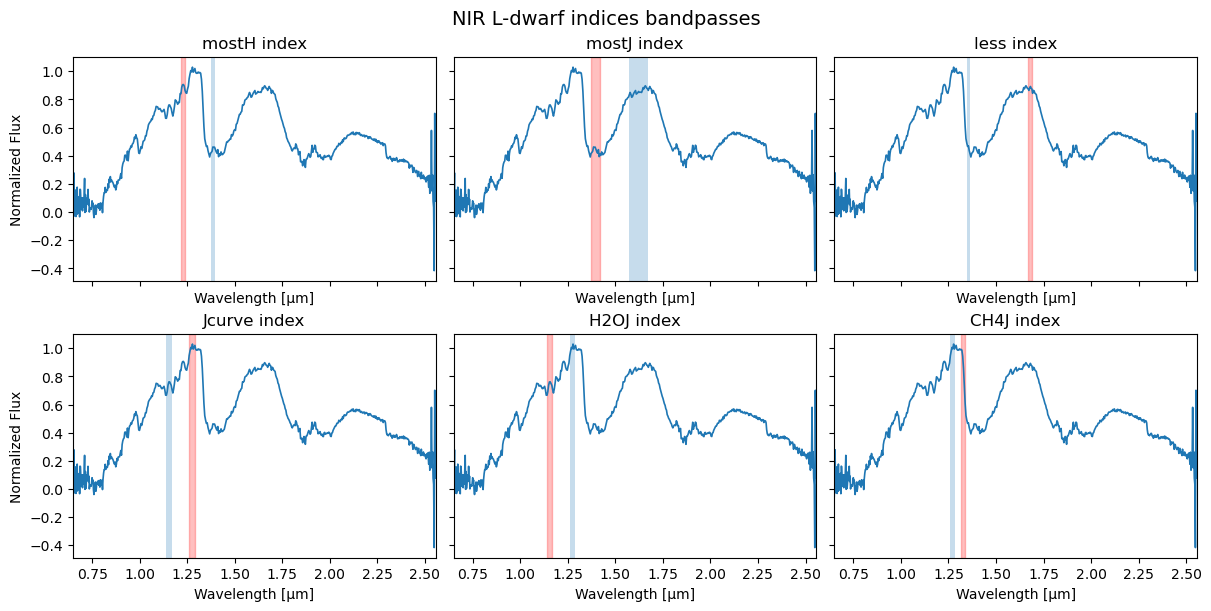

In [18]:
result = classify_variability(
    wave,
    flux,
    spectral_type="L",
    normalize=False,
    plot_index_windows=True,
)

This produces a multi-panel figure showing the input spectrum and the numerator/denominator wavelength windows used for each index in the selected L- or T-dwarf scheme.

If desired, the figure can be saved automatically:

### Plot the index–index variability diagrams
To reproduce the variability classification diagrams, set `plot_diagrams=True`.

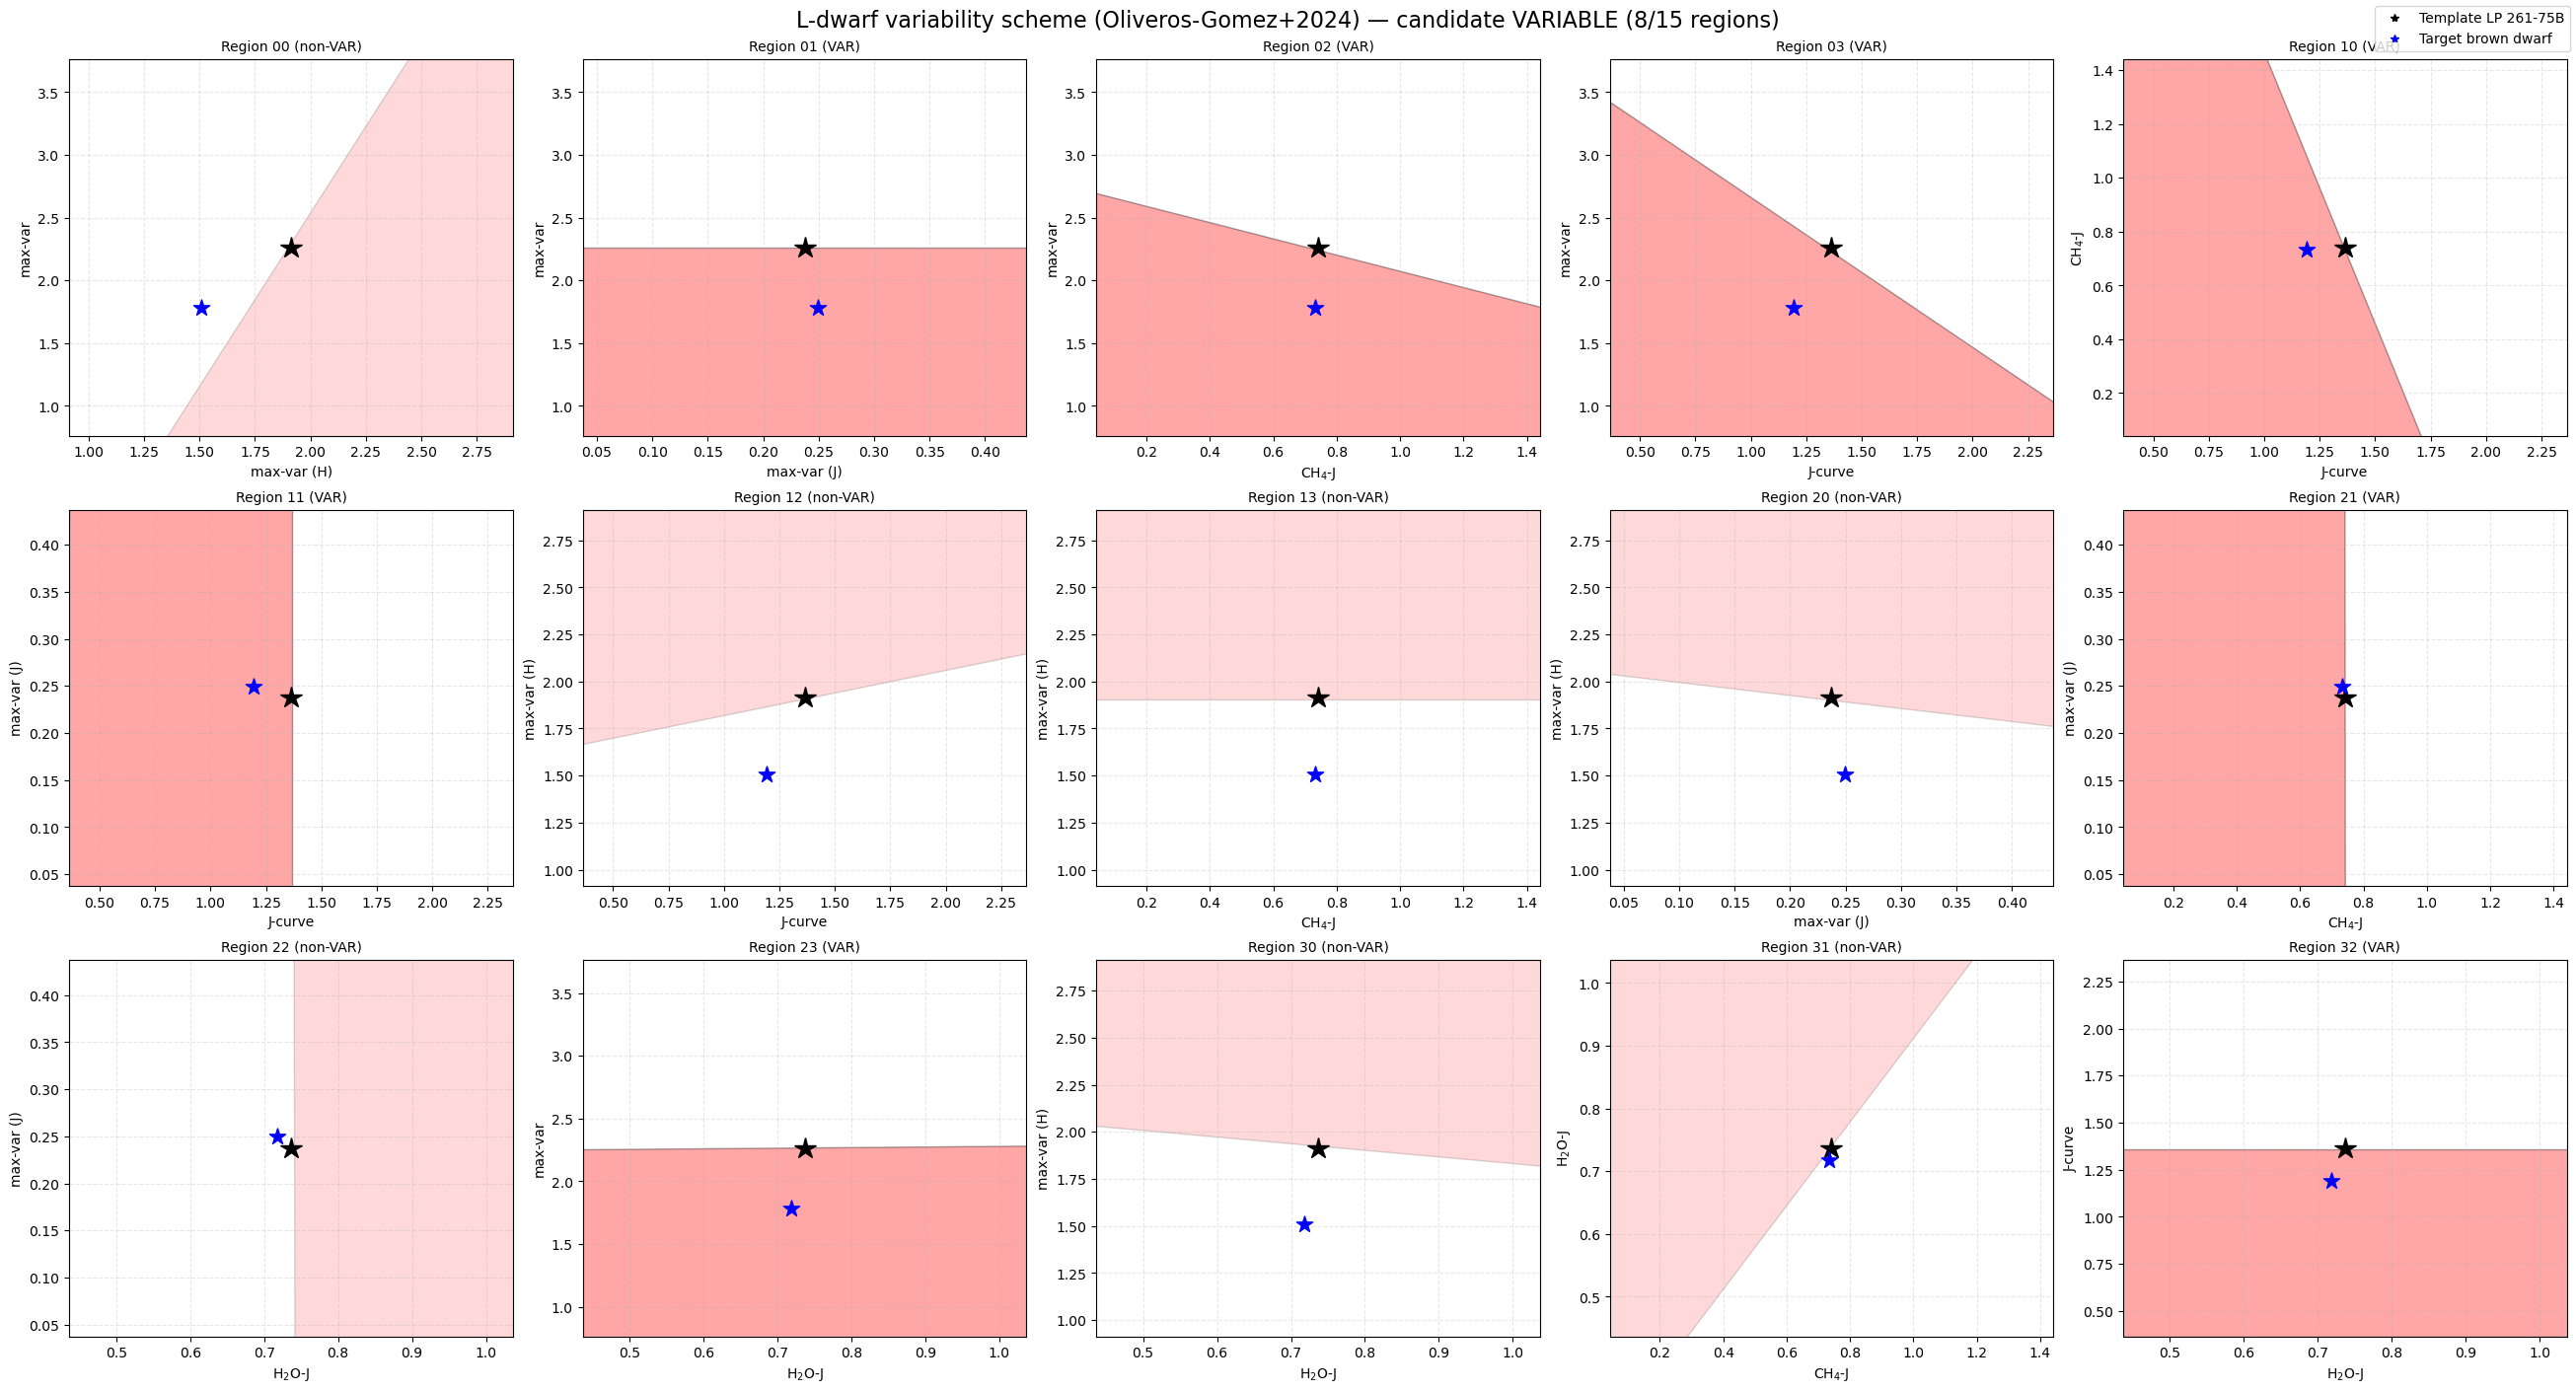

In [20]:
result = classify_variability(
    wave,
    flux,
    spectral_type="L",
    normalize=False,
    plot_diagrams=True,
)

These diagrams show:
- the polygonal variability regions,
- the template/reference object,
- and the position of the target object in index–index space.

You can also save the figure:

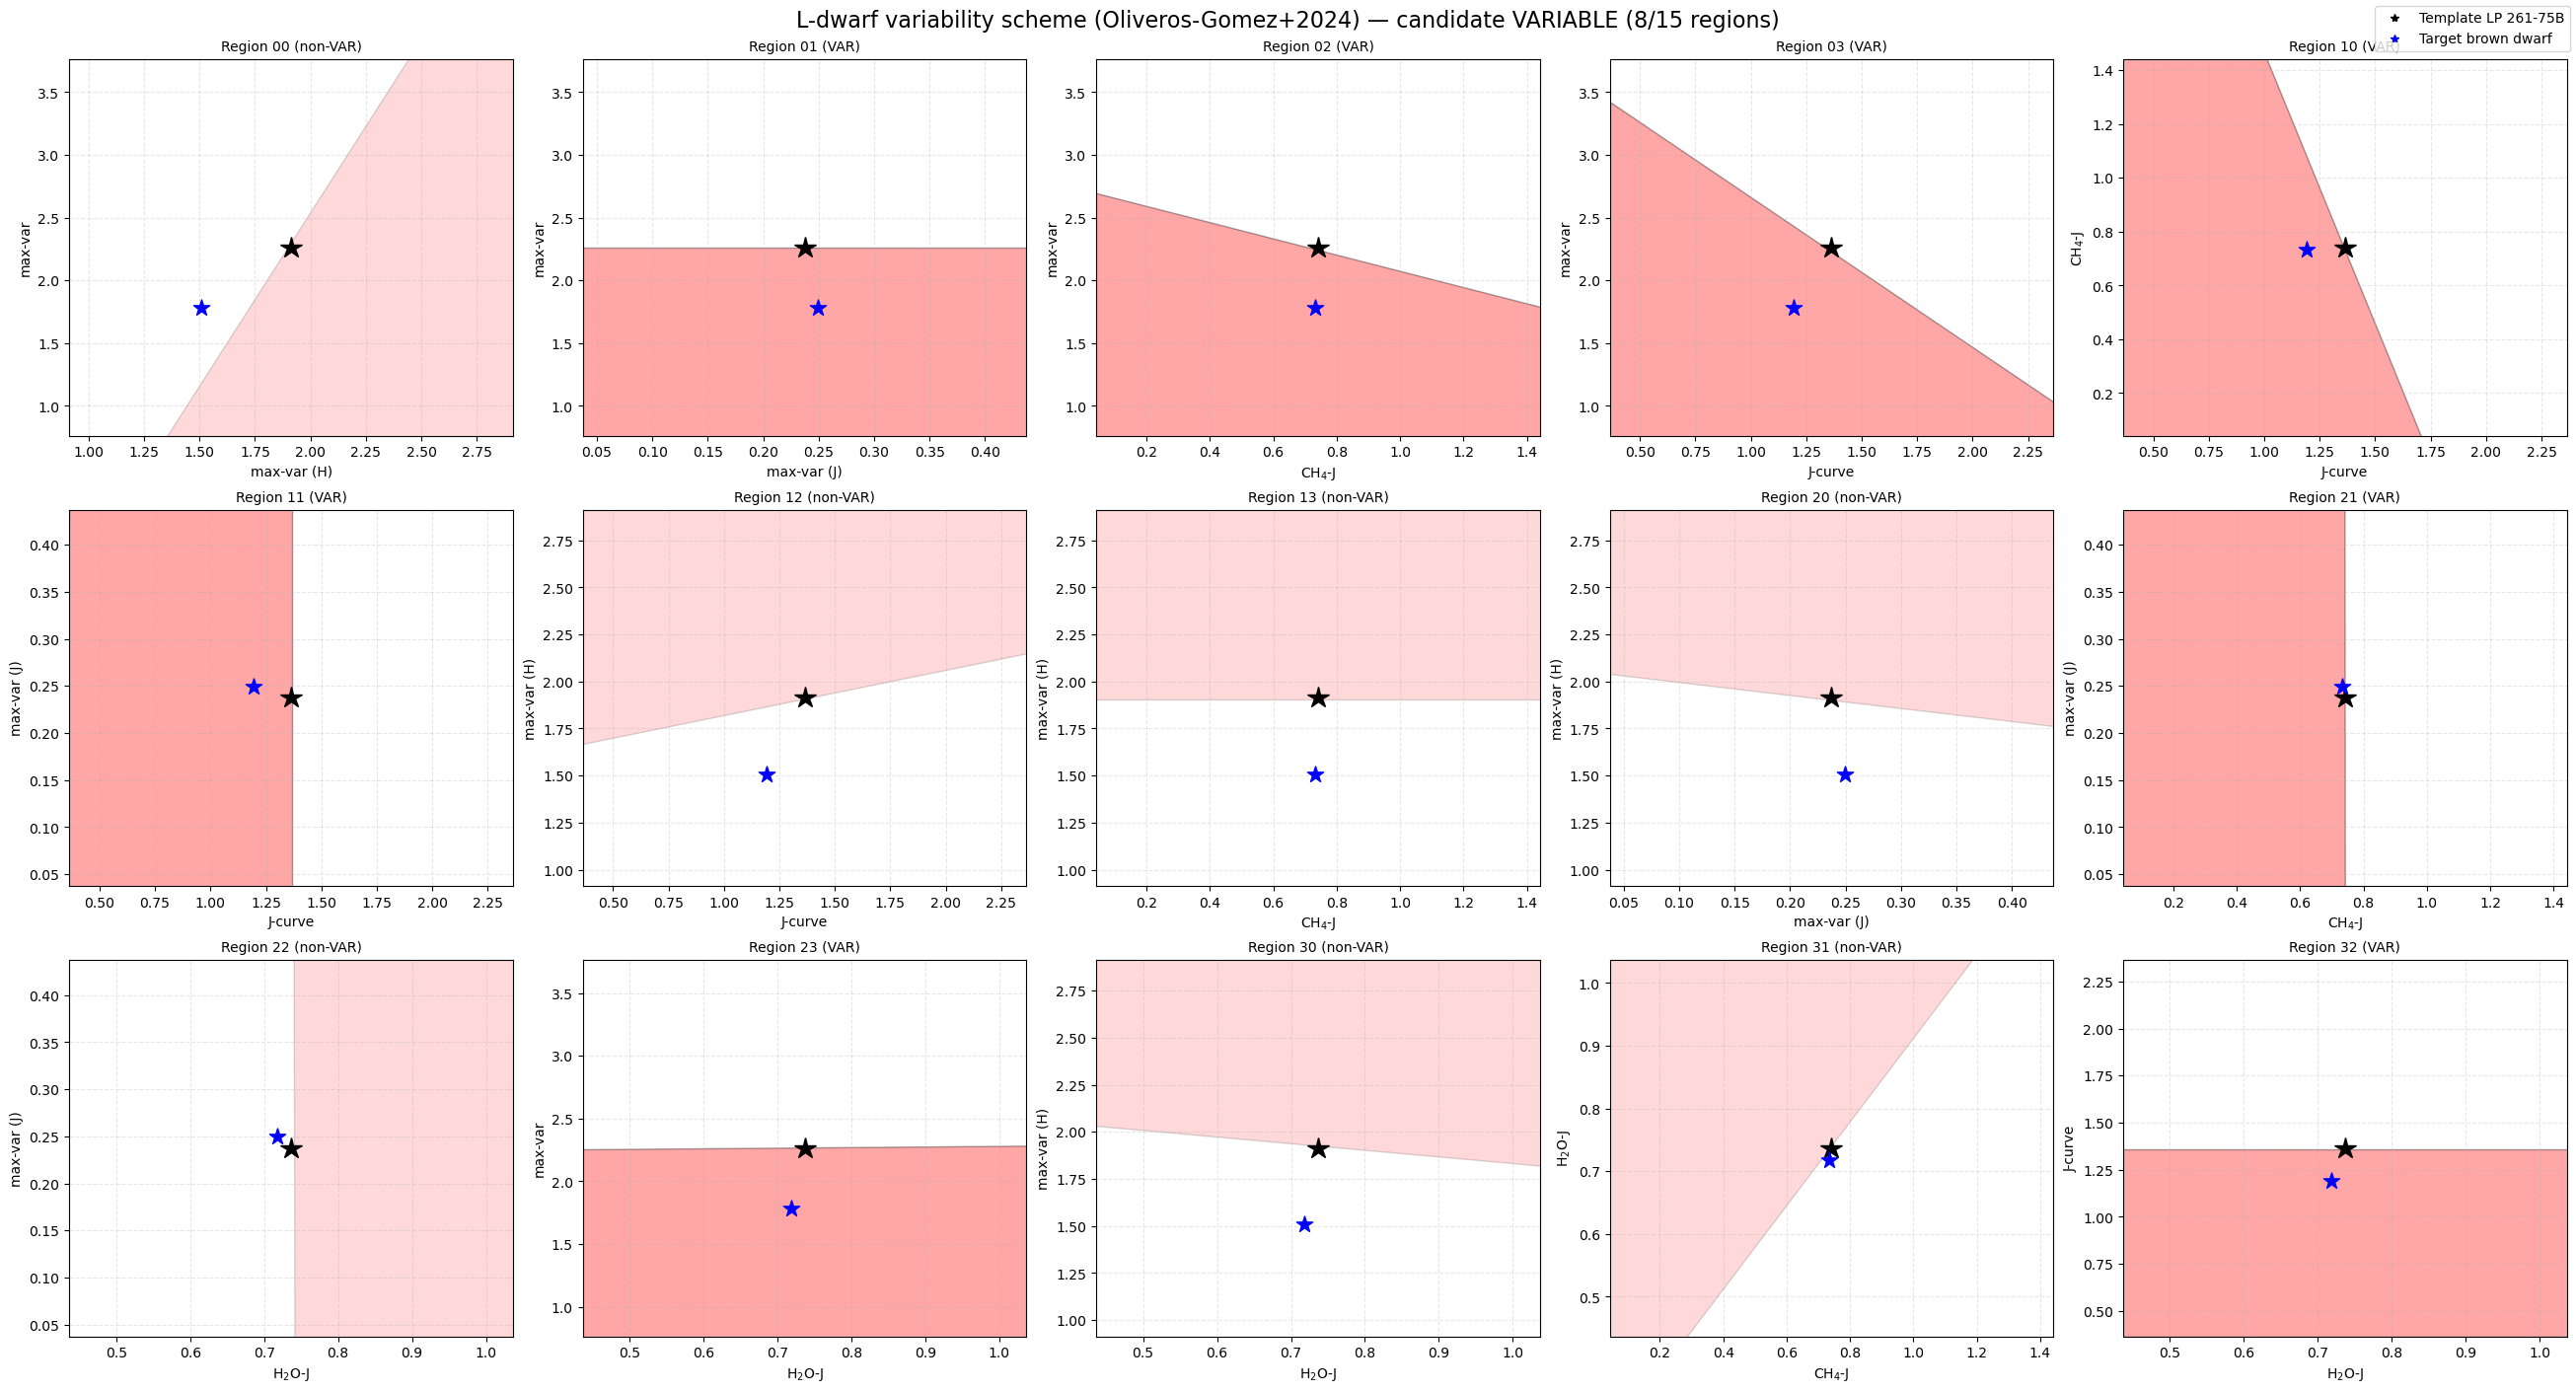

In [21]:
result = classify_variability(
    wave,
    flux,
    spectral_type="L",
    normalize=False,
    plot_diagrams=True,
    plot_save=True,
)

### Generate both diagnostic plots at once

Both the index-window plot and the index–index diagrams can be generated in a single call:

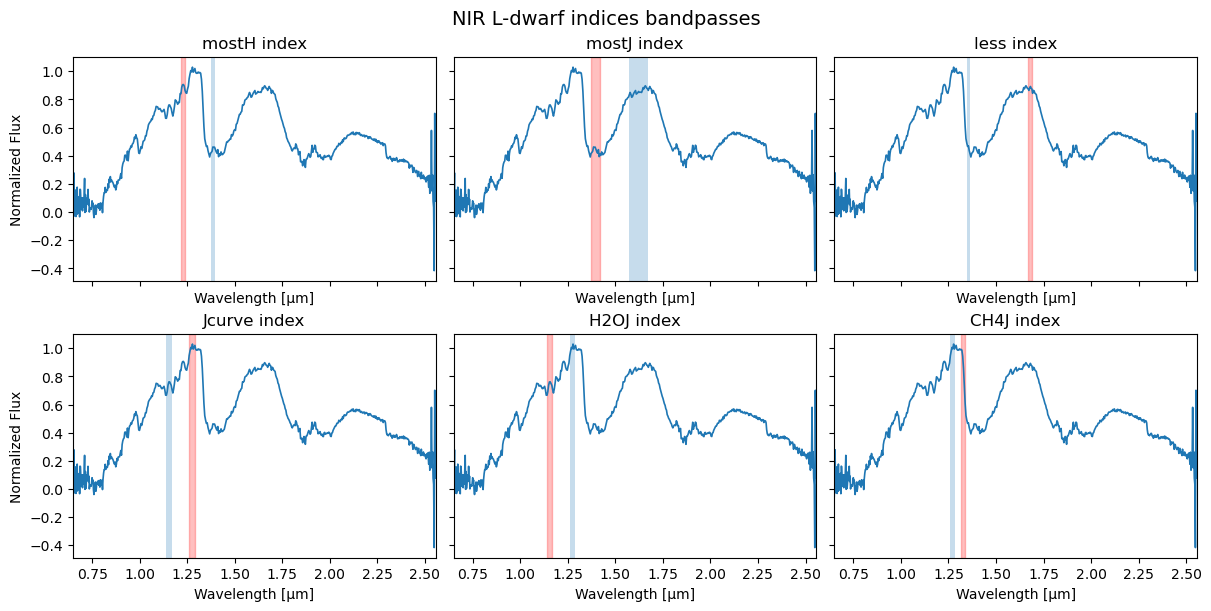

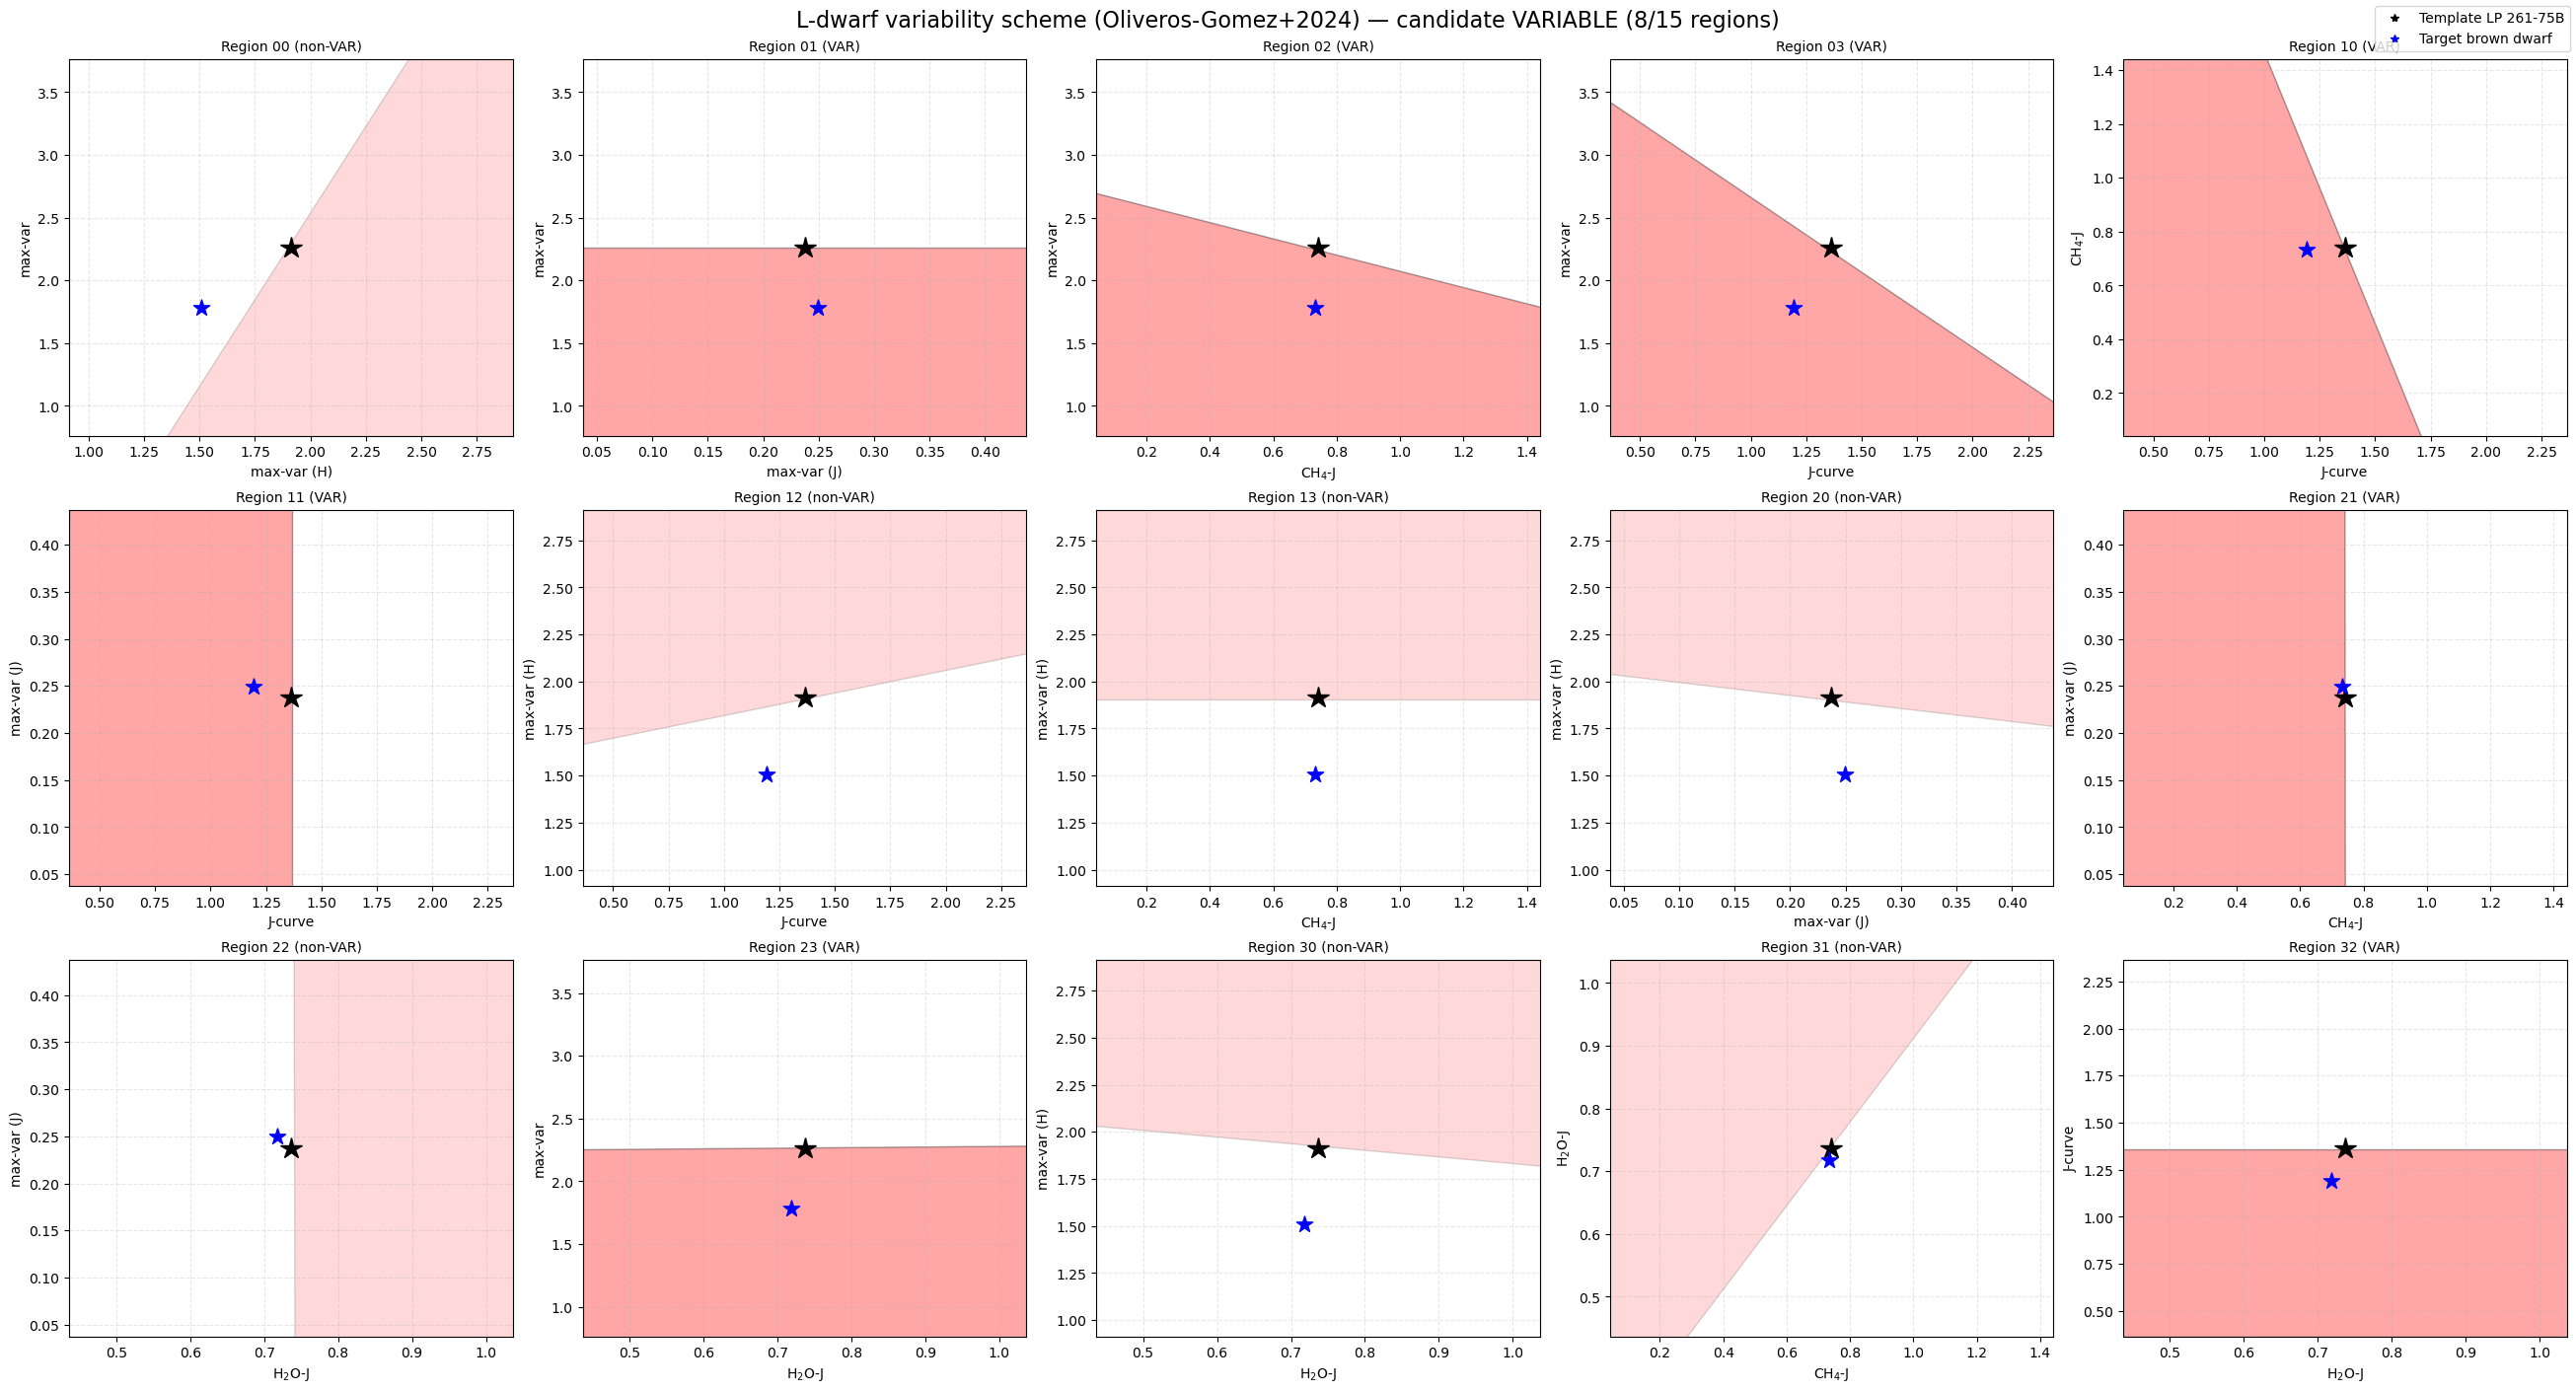

In [22]:
result = classify_variability(
    wave,
    flux,
    spectral_type="L",
    normalize=False,
    plot_index_windows=True,
    plot_diagrams=True,
)

### Example using the T-dwarf scheme
The same workflow applies to T dwarfs by changing the selected spectral type:

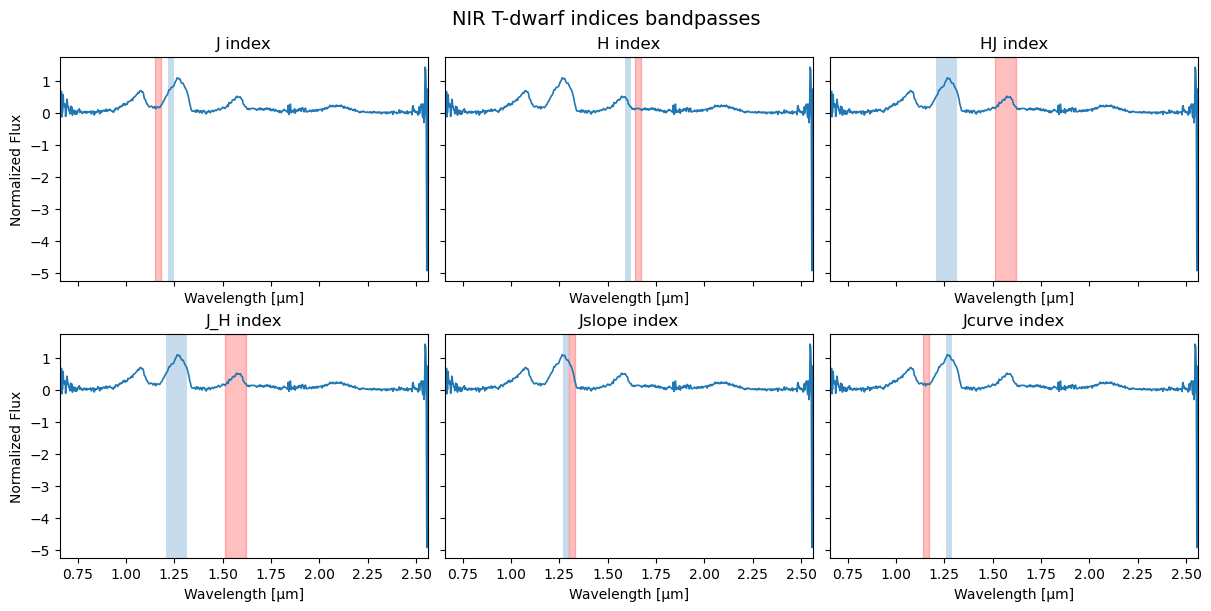

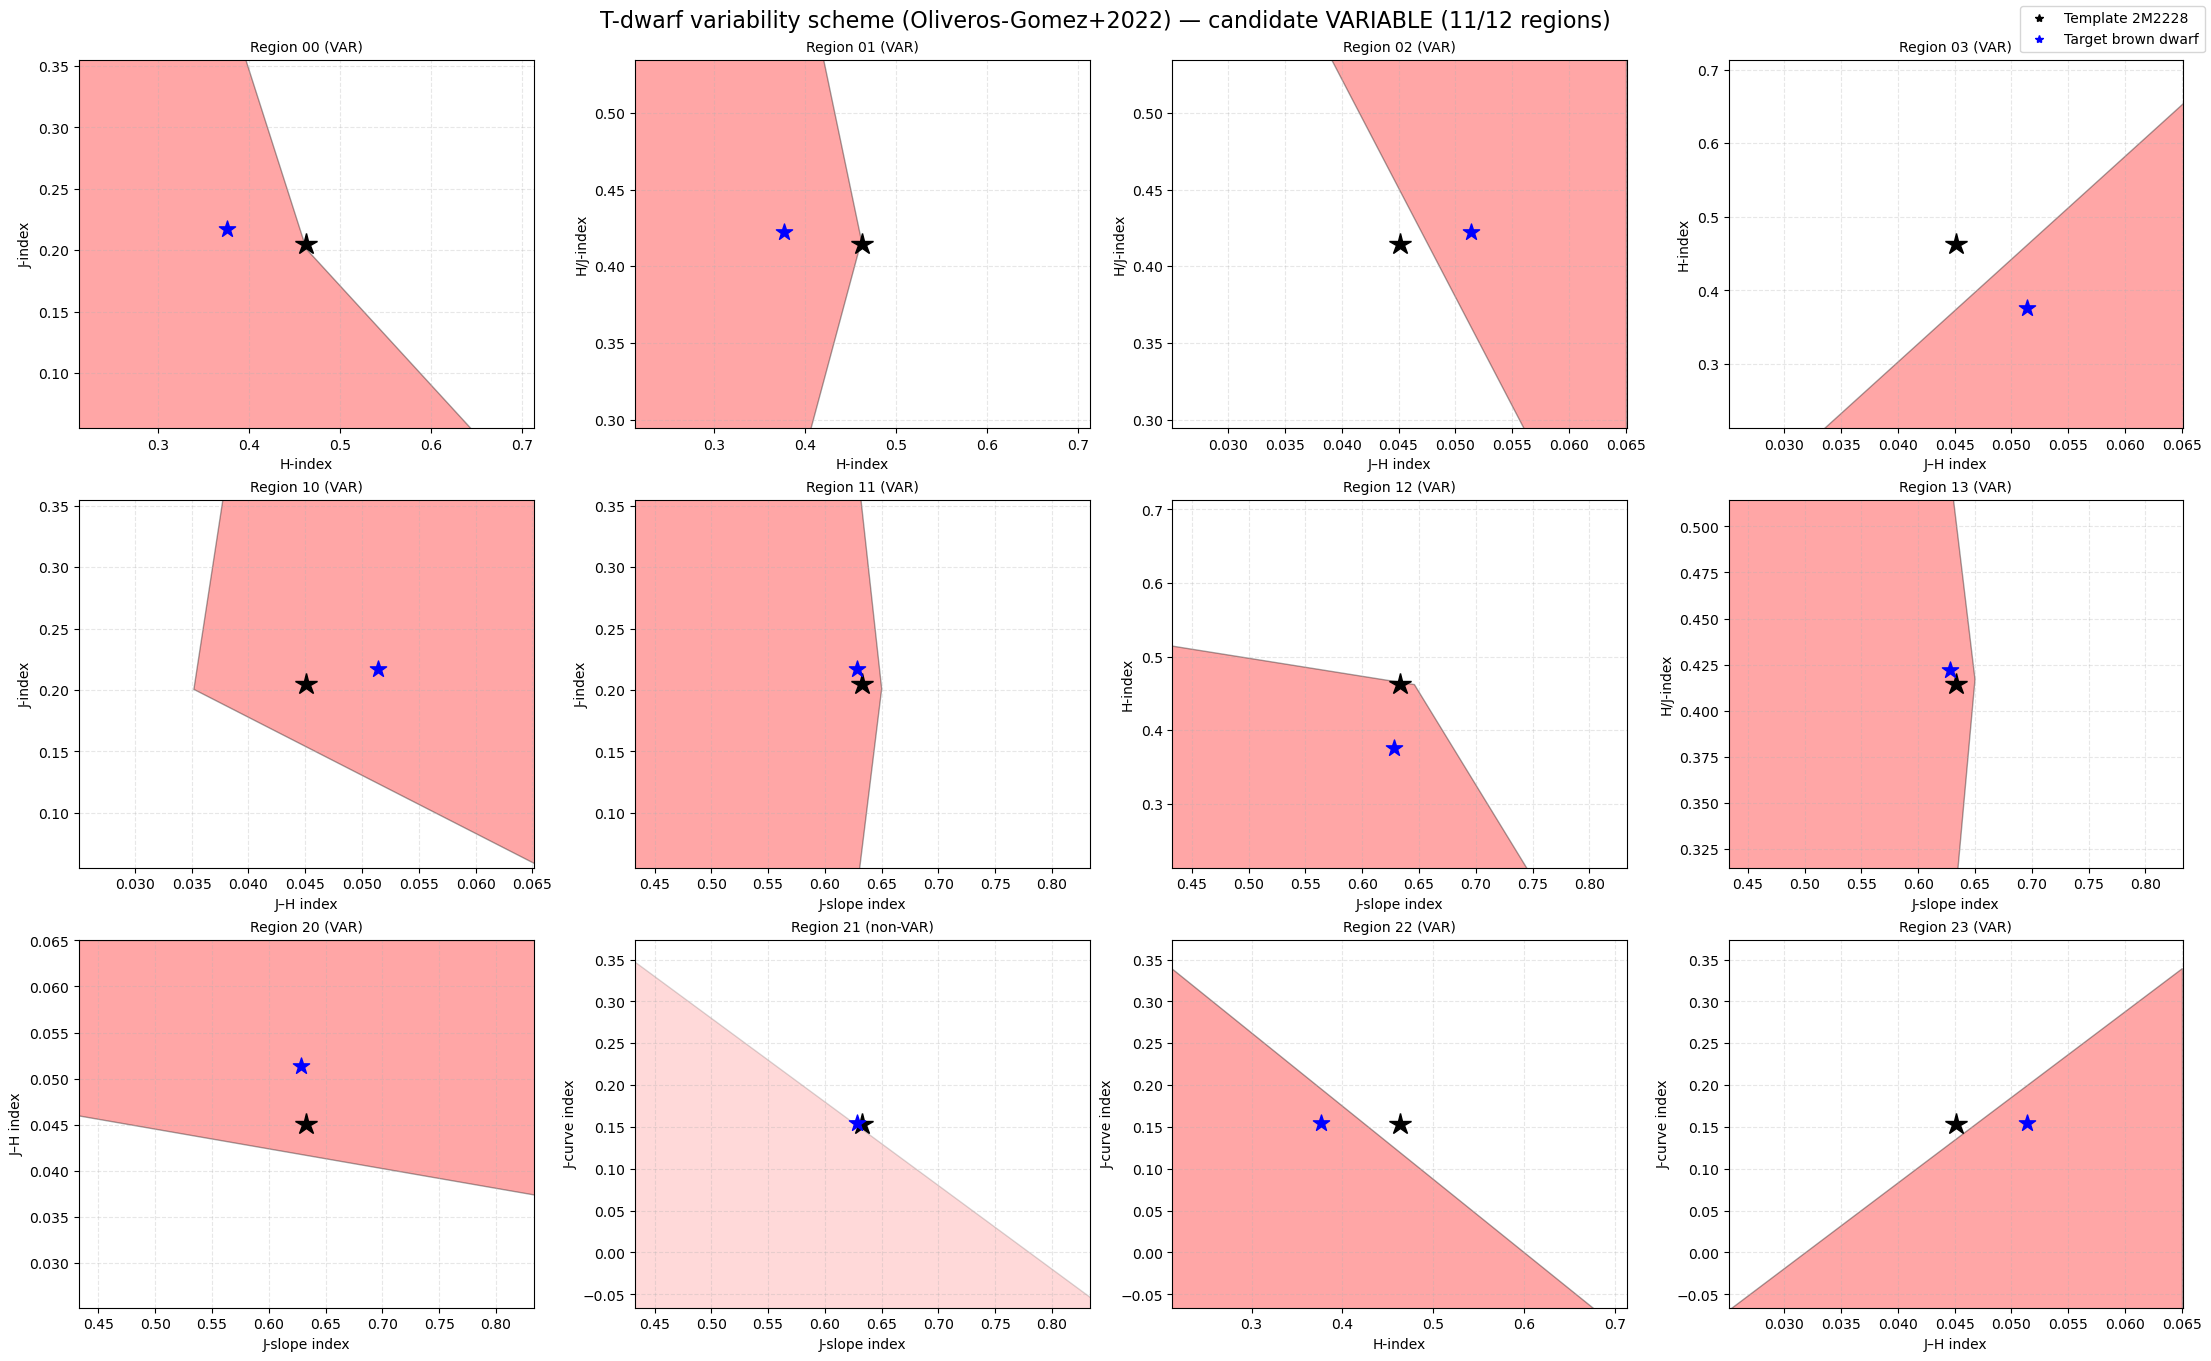

Scheme: Oliveros-Gomez+2022
Spectral type: T
Triggered regions: 11/12 (threshold ≥ 10)
Classification: candidate VARIABLE


In [24]:
# read the T-dwarf spectrum
spec_name = '/Users/arrecifecosmico/seda/docs/notebooks/data/2228-nirspec-Tdwarf.txt'
spec = np.loadtxt(spec_name, comments='#').T

wave = spec[0]   # wavelength in microns
flux = spec[1]   # flux

result_T = classify_variability(
    wave,
    flux,
    spectral_type="T",
    normalize=False,
    plot_index_windows=True,
    plot_diagrams=True,
)

print(result_T.summary())

### Notes on normalization

The normalize parameter should be chosen consistently with the input spectrum and the intended use of the indices.

- If the spectrum is already normalized, use normalize=False.

- If the spectrum is not normalized and you want SEDA to apply a median normalization, use normalize=True.

This is especially important for difference-type indices, whose absolute scale depends on the adopted normalization.

### Summary

`seda.classify_variability` provides a single high-level entry point to:

- compute the NIR variability indices,

- classify the target as candidate variable or non-variable,

- inspect the numerical results,

- and generate diagnostic plots.

This makes it straightforward to apply the variability scheme to individual L and T brown dwarf spectra.